# 1. Conceptual Framing: What Are Climate Extremes?

Climate change is often described in terms of global mean temperature. 
However, impacts on society and ecosystems are typically driven not by averages, 
but by extreme events.

A shift in the mean climate state can alter:

- **Frequency** – How often extreme events occur.
- **Intensity** – How severe those events become.
- **Duration** – How long extreme events persist.
- **Spatial distribution** – Where extremes occur and how patterns shift.

Examples of climate extremes include:

- Heatwaves
- Heavy rainfall events
- Droughts
- Severe storms

These extremes drive real-world consequences:

- Economic losses
- Infrastructure damage
- Agricultural failure
- Public health crises

Understanding changes in extremes is therefore central to climate adaptation 
and risk assessment.

## Mean vs Extremes

A common misconception is that a small increase in average temperature 
implies a small increase in risk.

In reality, even a modest shift in the mean of a climate variable 
can substantially increase the probability of extreme events.

This occurs because extremes lie in the *tails* of the distribution.

When the entire distribution shifts:

- The area under the extreme tail can grow rapidly.
- The frequency of rare events can increase disproportionately.
- Risk can increase nonlinearly.

Thus:

A small shift in the mean can produce a large increase in extreme heat days.

### Visualizing Distribution Shift and Tail Amplification

To illustrate how small changes in mean climate can amplify extremes,
we simulate two temperature distributions:

- Baseline climate
- Shifted climate (+1°C mean increase)

We then compare the probability of exceeding an extreme threshold.

Extreme threshold (baseline 95th percentile): 1.647
P(X > threshold) baseline: 0.050
P(X > threshold) shifted (+1): 0.258
Risk ratio (shifted / baseline): 5.17x
Absolute increase: 0.208


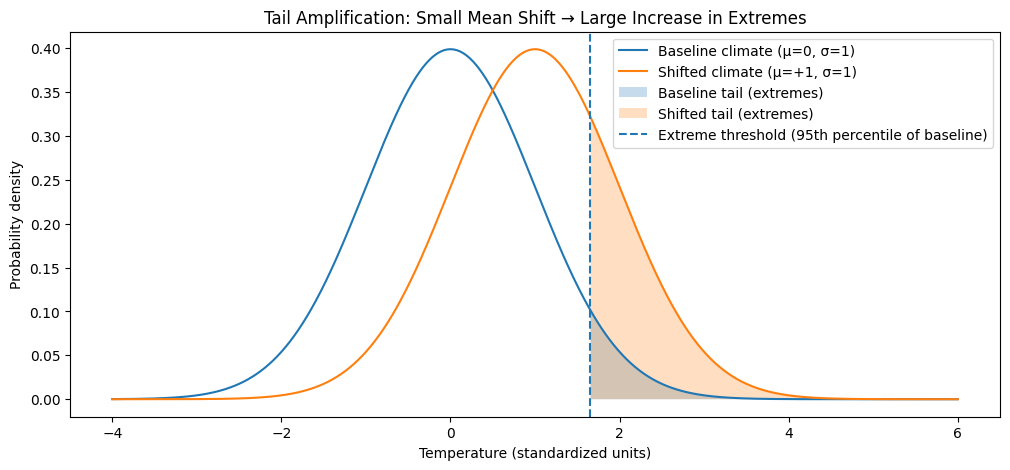

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

# -----------------------------
# 1) Generate synthetic distributions
# -----------------------------
np.random.seed(42)

n = 200_000
mu_baseline, sigma = 0.0, 1.0
mu_shifted = 1.0  # +1°C shift (in standardized units)

baseline = np.random.normal(mu_baseline, sigma, n)
shifted = np.random.normal(mu_shifted, sigma, n)

# -----------------------------
# 2) Define an "extreme" threshold
#    Use the 95th percentile of the baseline distribution
# -----------------------------
threshold = np.percentile(baseline, 95)

# -----------------------------
# 3) Compute exceedance probabilities
# -----------------------------
p_baseline = np.mean(baseline > threshold)
p_shifted = np.mean(shifted > threshold)

risk_ratio = p_shifted / p_baseline if p_baseline > 0 else np.nan
risk_diff = p_shifted - p_baseline

print(f"Extreme threshold (baseline 95th percentile): {threshold:.3f}")
print(f"P(X > threshold) baseline: {p_baseline:.3f}")
print(f"P(X > threshold) shifted (+1): {p_shifted:.3f}")
print(f"Risk ratio (shifted / baseline): {risk_ratio:.2f}x")
print(f"Absolute increase: {risk_diff:.3f}")

# -----------------------------
# 4) Plot both distributions as density curves
# -----------------------------
x = np.linspace(-4, 6, 800)

def normal_pdf(x, mu, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

pdf_baseline = normal_pdf(x, mu_baseline, sigma)
pdf_shifted = normal_pdf(x, mu_shifted, sigma)

plt.figure(figsize=(12, 5))

# Density curves
plt.plot(x, pdf_baseline, label="Baseline climate (μ=0, σ=1)")
plt.plot(x, pdf_shifted, label="Shifted climate (μ=+1, σ=1)")

# Shade the tail beyond the threshold for each distribution
x_tail = x[x >= threshold]
plt.fill_between(x_tail, normal_pdf(x_tail, mu_baseline, sigma), alpha=0.25, label="Baseline tail (extremes)")
plt.fill_between(x_tail, normal_pdf(x_tail, mu_shifted, sigma), alpha=0.25, label="Shifted tail (extremes)")

# Threshold line
plt.axvline(threshold, linestyle="--", linewidth=1.5, label="Extreme threshold (95th percentile of baseline)")

plt.title("Tail Amplification: Small Mean Shift → Large Increase in Extremes")
plt.xlabel("Temperature (standardized units)")
plt.ylabel("Probability density")
plt.legend()
plt.show()

### Interpretation

Although the mean temperature increased by only 1°C, 
the probability of exceeding the extreme threshold increased substantially.

This demonstrates a key principle:

    Extreme risk is highly sensitive to shifts in the mean state.

Therefore, monitoring changes in extremes is essential 
for understanding climate impacts.

Note that real climate distributions may not be perfectly normal. 
Changes in variance, skewness, and persistence can further amplify extremes.

Thus, analyzing extremes requires both statistical and physical insight.

# 2. The ETCCDI Framework

The Expert Team on Climate Change Detection and Indices (ETCCDI) 
developed a standardized set of climate extreme indices.

The purpose of ETCCDI is to:

- Provide consistent definitions of extremes
- Enable comparison across regions
- Ensure reproducibility across datasets
- Support climate change detection studies

Rather than relying on arbitrary thresholds, ETCCDI defines 
extreme indices using percentile-based or physically meaningful metrics.

The ETCCDI framework is widely used in IPCC assessments and 
peer-reviewed climate research.

### TXx – Annual Maximum Daily Maximum Temperature

TXx represents the highest daily maximum temperature observed 
within a given year.

Mathematically:

$$
TXx_y = \max_{i \in y} (T_{max,i})
$$

Where:
- $T_{max,i}$ is the daily maximum temperature on day $i$
- $y$ denotes a given year

TXx measures the intensity of the most extreme heat event each year.

### TNn – Annual Minimum Daily Minimum Temperature

TNn represents the lowest daily minimum temperature observed 
within a given year.

$$
TNn_y = \min_{i \in y} (T_{min,i})
$$

This index captures extreme cold events.

### R95p – Very Wet Days

R95p measures the total precipitation from days exceeding 
the 95th percentile of wet-day precipitation during a reference period.

Let $P_i$ denote daily precipitation on day $i$.

First define the threshold:

$$
P_{95} = \text{95th percentile of } P_i \text{ during reference period}
$$

Then compute:

$$
R95p_y = \sum_{i \in y, \, P_i > P_{95}} P_i
$$

This index captures changes in heavy rainfall intensity.

Percentile-based thresholds adapt to local climate conditions, 
making indices comparable across regions.

### CDD – Consecutive Dry Days

CDD measures the longest stretch of consecutive days 
with precipitation below a specified threshold (commonly 1 mm).

Let:

$$
D_i =
\begin{cases}
1 & \text{if } P_i < 1 \text{ mm} \\
0 & \text{otherwise}
\end{cases}
$$

CDD is defined as:

$$
CDD_y = \max (\text{length of consecutive sequences where } D_i = 1)
$$

This index captures drought duration.

## Why Standardized Indices Matter

Extreme indices provide:

- Reproducibility across studies
- Comparability across regions
- Consistent reference periods
- Robust statistical definitions

Without standardized definitions, 
"heatwave" or "heavy rainfall" could vary arbitrarily between studies.

Most ETCCDI indices are designed to detect:

- Changes in frequency
- Changes in intensity
- Changes in duration

Importantly, many indices rely on percentile-based thresholds 
defined relative to a baseline period (e.g., 1961–1990).

This ensures that changes reflect shifts in the distribution, 
not fixed absolute thresholds.

In the following sections, we will compute selected indices 
using observational or gridded datasets, 
and analyze how they evolve over time and space.

# 3. Data Sources 

## A. ETCCDI-Derived Extreme Indices

The ETCCDI framework defines standardized indices, but the indices themselves are often distributed as precomputed datasets.

The most widely used global dataset is:

    ETCCDI

ETCCDI-derived datasets are typically:

- Computed from daily temperature and precipitation observations
- Aggregated annually or seasonally
- Provided on gridded spatial products
- Available in NetCDF format

They include indices such as:
- TXx (annual maximum temperature)
- R95p (heavy rainfall days)
- CDD (consecutive dry days)

**Where to Access ETCCDI Data**

Several repositories provide precomputed indices:

- Climdex Project https://www.climdex.org/

- HadEX3 (Met Office) https://www.metoffice.gov.uk/hadobs/hadex3/
- Copernicus Climate Data Store (CDS)

These datasets are usually:
- NetCDF files
- Gridded products
- Ready for use with xarray

*Strengths:*
- Standardized methodology
- Long historical records
- International comparability

*Limitations:*
- Sparse station coverage in early decades
- Regional gaps
- Quality control differences across countries



## B. CHIRPS

    CHIRPS (Climate Hazards Group InfraRed Precipitation with Stations) is a high-resolution precipitation dataset.

It combines:
- Satellite-based rainfall estimates
- Ground station observations

**Key Characteristics:**
- Spatial resolution: 0.05° (~5 km)
- Temporal resolution: daily and monthly
- Coverage: 50°S–50°N
- Period: 1981–present


**Why CHIRPS is Useful**
- Suitable for heavy rainfall analysis
- Good for drought studies
- High spatial resolution
- Frequently used in agricultural risk analysis


**Accessing CHIRPS Data**

CHIRPS data can be accessed via:
- Climate Hazards Center: https://data.chc.ucsb.edu/products/CHIRPS-2.0/
- Google Earth Engine (Python API)
- Direct FTP download

Files are typically:
- NetCDF
- GeoTIFF
- Daily or monthly


*Strengths:*
- High spatial resolution
- Good coverage in developing regions
- Long consistent record

*Limitations:*
- Satellite-based estimates may contain bias
- Shorter record than temperature datasets

## C. NOAA Storm Events Database

This database contains:
 -Historical records of severe weather events
- Tornadoes
- Hurricanes
- Floods
- Extreme temperatures
- Damage estimates
- Casualty counts

**Why It’s Different**

Unlike gridded climate datasets:
- It is event-based
- It includes socioeconomic impacts
- It contains categorical event types


**Accessing NOAA Storm Events**

Data portal: https://www.ncei.noaa.gov/access/storm-events/

Data is available as:
- CSV files
- By year
- By event type
- API queries possible

*Strengths:*
- Detailed impact data
- Long historical archive
- Event-level resolution

*Limitations:*
- Reporting biases
- Changes in detection technology over time
- Inconsistent early reporting

### Different datasets represent different dimensions of extreme events:

- ETCCDI indices quantify physical climate extremes.
- CHIRPS provides high-resolution precipitation fields.
- NOAA Storm Events captures reported impacts.

A comprehensive climate risk assessment requires integrating
physical hazard data with exposure and vulnerability information.

In the following exercises, we will:

1. Compute or extract extreme indices.
2. Analyze temporal changes.
3. Map spatial patterns of extreme risk.    

# 4. Exercise Part A — Heatwave Days

### Definition (Percentile-Based Heatwave)

A heatwave day is defined as:

A day where daily maximum temperature exceeds 
the 90th percentile of daily maximum temperature 
during a reference baseline period.

To capture persistence, we define a heatwave event as:

At least 3 consecutive days exceeding this threshold.

### Mathematical Definition of a Heatwave

Let $T_{\text{max}, i}$ denote the daily maximum temperature on day $i$.

---

#### Baseline Threshold

For each calendar day $d$, we compute the 90th percentile of 
daily maximum temperature during a reference period 
(e.g., 1981–2010):

$$
T_{90}(d) = \text{Percentile}_{90}\left(T_{\text{max}}(d)\right)
$$

where:
- $T_{90}(d)$ is the 90th percentile threshold for calendar day $d$
- The percentile is computed using values from the baseline period only
- This allows thresholds to vary seasonally

---

#### Heatwave Condition

A day $i$ is classified as a heatwave day if:

$$
T_{\text{max}, i} > T_{90}(d)
$$

where $d$ corresponds to the calendar day of observation.

---

#### Heatwave Event Definition

A heatwave event is defined as:

At least 3 consecutive days satisfying

$$
T_{\text{max}, i} > T_{90}(d)
$$

Thus, persistence (duration) is incorporated into the definition.

**Why use percentile-based thresholds:**

Percentile-based thresholds adjust for local climate conditions.
A 35°C day may be extreme in Northern Europe 
but normal in Southern Spain.

Using percentiles ensures comparability across regions.

### Data Preparation Workflow

1. Load daily maximum temperature (Tmax).
2. Select regional subset (e.g., Central Europe).
3. Define baseline period (e.g., 1981–2010).
4. Compute 90th percentile threshold for each calendar day.
5. Identify exceedance days.
6. Identify sequences ≥ 3 consecutive days.
7. Count annual heatwave days.
8. Analyze trend.

### Data Source for Heatwave Analysis

We use *ERA5 hourly time-series data on single levels from 1940 to present* (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview) from Copernicus Climate Data Store.

- Variable: 2m temperature
- Frequency: Daily
- Period: 1991–2025
- Units: Kelvin (converted to Celsius)
- Location: For Berlin (≈ 52.52°N, 13.41°E) we use the nearest grid point: (52.50°N, 13.50°E).

Daily data are required to detect persistence and compute 
calendar-day percentile thresholds.


This time, we would be using **Copernicus CDS API (cdsapi)** to download the dataset. 

The Copernicus Climate Data Store (CDS) provides programmatic access to datasets such as ERA5. The official Python client library is cdsapi, which allows us to download data in a reproducible way (instead of manual clicks in the web UI).

**Prerequisites**

    A) Create a CDS account

Create an account on the Copernicus Climate Data Store and obtain your API key (shown on your CDS API page/profile).

    B) Install cdsapi

pip install cdsapi

    C) Configure credentials (.cdsapirc)

cdsapi reads credentials from a configuration file named:
- **Linux/macOS**: ~/.cdsapirc
- **Windows**: C:\Users\<YourUser>\.cdsapirc

For more info: https://cds.climate.copernicus.eu/how-to-api

In [17]:
import cdsapi
from datetime import datetime
import zipfile
import os
import xarray as xr

def download_and_open_era5_timeseries(request, zip_target, extract_dir):
    client = cdsapi.Client()

    start = datetime.now()
    print(f"Starting download: {start:%Y-%m-%d %H:%M:%S}")
    print("Target:", zip_target)

    client.retrieve("reanalysis-era5-single-levels-timeseries", request, zip_target)

    end = datetime.now()
    print(f"Finished download: {end:%Y-%m-%d %H:%M:%S}")
    print(f"Duration: {end - start}")

    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_target, "r") as z:
        z.extractall(extract_dir)
        names = z.namelist()
        print("Extracted:", names)

    # pick the first NetCDF file
    nc_candidates = [os.path.join(extract_dir, n) for n in names if n.endswith(".nc")]
    if not nc_candidates:
        raise FileNotFoundError("No .nc file found inside the downloaded ZIP.")

    nc_path = nc_candidates[0]
    print("Opening:", nc_path)

    return xr.open_dataset(nc_path)

# --- usage ---
berlin_location = {"latitude": 52.5, "longitude": 13.5}

request = {
    "variable": ["2m_temperature"],
    "location": berlin_location,
    "date": ["1991-01-01/2025-12-18"],
    "data_format": "netcdf",
}

# Step 1 — Load Data
ds = download_and_open_era5_timeseries(
    request=request,
    zip_target="era5_berlin_t2m_hourly_1991_2025.zip",
    extract_dir="era5_berlin_timeseries_extracted"
)

print(ds)


Starting download: 2026-02-23 19:40:48
Target: era5_berlin_t2m_hourly_1991_2025.zip


2026-02-23 19:40:49,485 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-02-23 19:40:49,487 INFO Request ID is 707805b8-65f8-4b7d-aefb-70af9c3d6441
2026-02-23 19:40:49,669 INF

a8a046909acead9acf989023ab67b6b0.zip:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

Finished download: 2026-02-23 19:41:14
Duration: 0:00:25.839201
Extracted: ['reanalysis-era5-single-levels-timeseries-sfc63qwb7ba.nc']
Opening: era5_berlin_timeseries_extracted/reanalysis-era5-single-levels-timeseries-sfc63qwb7ba.nc
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 306504)
Coordinates:
    latitude    float64 8B ...
    longitude   float64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2MB 1991-01-01 ... 2025-12-18T23:...
Data variables:
    t2m         (valid_time) float32 1MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts


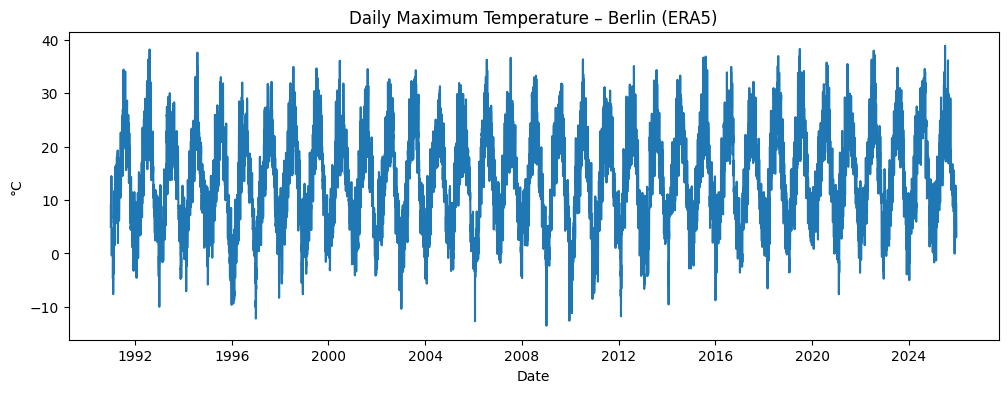

In [21]:
# TODO:
# - Load daily temperature data
# - Compute 90th percentile baseline (reference period)
# - Count days exceeding threshold per year
# - Plot trend in heatwave days


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 2 — Convert to Celsius
t2m_c = ds["t2m"] - 273.15
t2m_c.name = "t2m_c"

# Step 3 — Compute Daily Maximum Temperature
tmax_daily = t2m_c.resample(valid_time="1D").max()
tmax_daily.name = "tmax"

# Quick sanity plot:
plt.figure(figsize=(12,4))
tmax_daily.plot()
plt.title("Daily Maximum Temperature – Berlin (ERA5)")
plt.ylabel("°C")
plt.xlabel("Date")
plt.show()

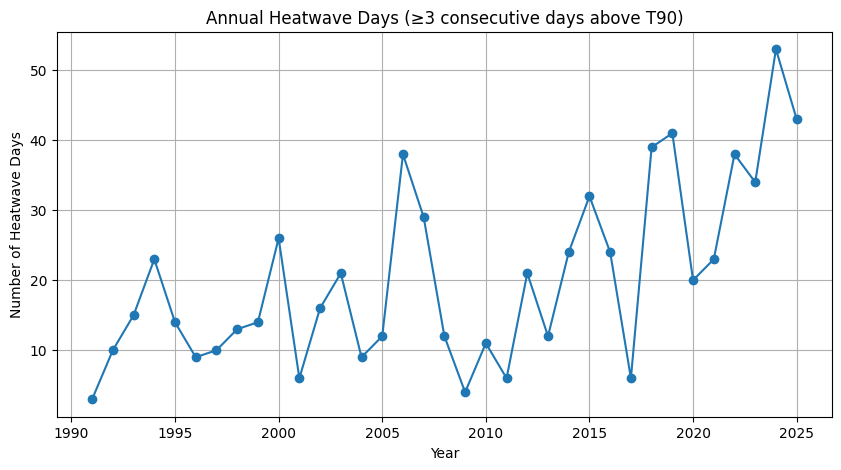

In [28]:

#  Step 4 — Define Baseline Period 1991–2020
baseline = tmax_daily.sel(valid_time=slice("1991-01-01", "2020-12-31"))

# Step 5 — Compute 90th Percentile per Calendar Day
# Add day-of-year coordinate
baseline_doy = baseline.groupby("valid_time.dayofyear")

t90 = baseline_doy.reduce(
    np.nanpercentile,
    q=90
)

# Step 6 — Apply Threshold to Full Dataset
# Add day-of-year to full dataset
doy = tmax_daily["valid_time"].dt.dayofyear

# Map thresholds onto full time series
threshold = xr.DataArray(
    t90.sel(dayofyear=doy).values,
    coords={"valid_time": tmax_daily.valid_time},
    dims=["valid_time"]
)

# Identify exceedances
exceedance = tmax_daily > threshold

# Step 7 — Identify Heatwave Events (≥3 consecutive days)
# Convert to pandas for easier sequence detection
exceed_series = exceedance.to_series()

# Identify runs of consecutive True values
heatwave_days = []
current_run = []

for date, is_hot in exceed_series.items():
    if is_hot:
        current_run.append(date)
    else:
        if len(current_run) >= 3:
            heatwave_days.extend(current_run)
        current_run = []

# Handle case where series ends in heatwave
if len(current_run) >= 3:
    heatwave_days.extend(current_run)

heatwave_days = pd.to_datetime(heatwave_days)

# Step 8 — Count Heatwave Days per Year
heatwave_df = pd.DataFrame(index=heatwave_days)
heatwave_df["year"] = heatwave_df.index.year

annual_counts = heatwave_df.groupby("year").size()

# Fill missing years with 0:
all_years = pd.Series(
    0,
    index=np.arange(1991, 2026)
)

annual_counts = all_years.add(annual_counts, fill_value=0)

# Step 9 — Plot Trend
plt.figure(figsize=(10,5))
plt.plot(annual_counts.index, annual_counts.values, marker="o")
plt.title("Annual Heatwave Days (≥3 consecutive days above T90)")
plt.xlabel("Year")
plt.ylabel("Number of Heatwave Days")
plt.grid(True)
plt.show()


**Visual Pattern**

The annual number of heatwave days (defined as ≥3 consecutive days above the 1991–2020 90th percentile threshold) shows a clear upward trend.
- Early 1990s: mostly single-digit or low double-digit heatwave days.
- Post-2010 period: frequent years above 30 days.
- 2024 appears as an extreme year (>50 days).

This indicates that extreme heat persistence has increased substantially in recent decades.

### Add Mann–Kendall Test: 

In [29]:
import pymannkendall as mk

mk_result = mk.original_test(annual_counts.values)

print("Trend:", mk_result.trend)
print("p-value:", mk_result.p)
print("Sen's slope:", mk_result.slope)

Trend: increasing
p-value: 0.000831259146470531
Sen's slope: 0.75


- The p-value (< 0.001) indicates that the upward trend is statistically significant.
- We reject the null hypothesis of “no monotonic trend”.
- The probability that this trend occurred by random variability alone is <0.1%.

### Practical Significance

This is not only statistically significant — it is practically significant.

An increase of:
- ~20+ heatwave days over three decades
- nearly doubling (or more) compared to early 1990s

has implications for:
- Public health (heat stress, mortality)
- Energy demand (cooling)
- Urban infrastructure
- Water management
- Labor productivity

# 5. Exercise Part B — Heavy Rainfall Days

## What Is Extreme Rainfall?

Extreme precipitation events are often more damaging than gradual changes in mean rainfall.

Impacts include:
- Flash flooding
- River overflow
- Urban drainage failure
- Soil erosion
- Infrastructure damage

Unlike temperature extremes, rainfall extremes are:
- Highly localized
- Highly variable
- Often non-normally distributed (heavy-tailed)

## Defining Heavy Rainfall

There are two common approaches:

### A) Percentile-based threshold (relative extreme)

We define extreme rainfall days relative to local climatology.

Let:

$$
P_i = \text{daily precipitation on day } i
$$

Define the 95th percentile threshold:

$$
P_{95} = 95th \text{ percentile of daily precipitation during baseline period } 
$$

Then an extreme rainfall day is:
$$
P_i > P_{95}
$$

### B) Absolute threshold (impact-based)

Define extreme rainfall using a fixed value:

$$
P_i > 20 mm / day
$$

This is useful when focusing on flood-relevant rainfall intensity.

## Why Two Definitions?
- Percentile-based → Climate signal detection
- Absolute threshold → Impact & risk analysis

Both are used in climate science.

For this exercise, we will demonstrate both.

## When it comes to datasets, we could use: CHIRPS

**CHIRPS (Climate Hazards Group InfraRed Precipitation with Stations)** is:
- A high-resolution rainfall dataset
- 0.05° grid (~5 km resolution)
- Daily temporal resolution
- Available from 1981–present
- Combines satellite estimates with in-situ station data

CHIRPS is widely used for:
- Drought monitoring
- Extreme rainfall analysis
- Food security applications
- Climate variability studies

Dataset link: https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p05/

But since downloading the dataset for 2010-2024 at least, would be 15GB+download,

We will be going to use again era5 from the previous 

**ERA5 hourly time-series data on single levels from 1940 to present** 

dataset, by chosing "Total precipitation" as variable:

In [30]:
import cdsapi
from datetime import datetime
import zipfile
import os
import xarray as xr

def download_and_open_era5_timeseries(request, zip_target, extract_dir):
    client = cdsapi.Client()

    start = datetime.now()
    print(f"Starting download: {start:%Y-%m-%d %H:%M:%S}")
    print("Target:", zip_target)

    client.retrieve("reanalysis-era5-single-levels-timeseries", request, zip_target)

    end = datetime.now()
    print(f"Finished download: {end:%Y-%m-%d %H:%M:%S}")
    print(f"Duration: {end - start}")

    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_target, "r") as z:
        z.extractall(extract_dir)
        names = z.namelist()
        print("Extracted:", names)

    # pick the first NetCDF file
    nc_candidates = [os.path.join(extract_dir, n) for n in names if n.endswith(".nc")]
    if not nc_candidates:
        raise FileNotFoundError("No .nc file found inside the downloaded ZIP.")

    nc_path = nc_candidates[0]
    print("Opening:", nc_path)

    return xr.open_dataset(nc_path)

# --- usage ---
berlin_location = {"latitude": 52.5, "longitude": 13.5}

request = {
    "variable": ["total_precipitation"],
    "location": berlin_location,
    "date": ["1991-01-01/2025-12-18"],
    "data_format": "netcdf",
}

# Step 1 — Load Data
ds = download_and_open_era5_timeseries(
    request=request,
    zip_target="era5_berlin_precipitation_hourly_1991_2025.zip",
    extract_dir="era5_berlin_precipitation_timeseries_extracted"
)

print(ds)

Starting download: 2026-02-23 20:55:35
Target: era5_berlin_precipitation_hourly_1991_2025.zip


2026-02-23 20:55:36,027 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-02-23 20:55:36,030 INFO Request ID is 8f34361a-c0da-4fd6-a19e-73289e737aa0
2026-02-23 20:55:36,149 INF

360ae084ecb585cf6c10a46e708892bd.zip:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

Finished download: 2026-02-23 20:55:49
Duration: 0:00:13.916490
Extracted: ['reanalysis-era5-single-levels-timeseries-sfc57_1n1l2.nc']
Opening: era5_berlin_precipitation_timeseries_extracted/reanalysis-era5-single-levels-timeseries-sfc57_1n1l2.nc
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 306504)
Coordinates:
    latitude    float64 8B ...
    longitude   float64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2MB 1991-01-01 ... 2025-12-18T23:...
Data variables:
    tp          (valid_time) float32 1MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts


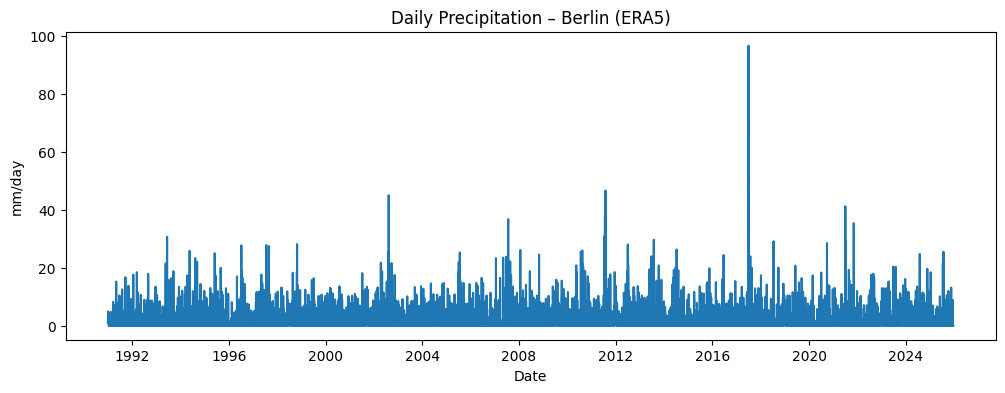

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

ds2 = ds.rename({"valid_time": "time"})

# Step 1 — Convert hourly precipitation to mm
# tp is in meters; convert to millimeters
tp_mm = ds2["tp"] * 1000.0
tp_mm.name = "tp_mm"

# Step 2 — Compute daily rainfall totals (mm/day)
pr_daily = tp_mm.resample(time="1D").sum()
pr_daily.name = "pr_daily_mm"

plt.figure(figsize=(12,4))
pr_daily.plot()
plt.title("Daily Precipitation – Berlin (ERA5)")
plt.ylabel("mm/day")
plt.xlabel("Date")
plt.show()

P95 threshold (mm/day): 12.215137481689453


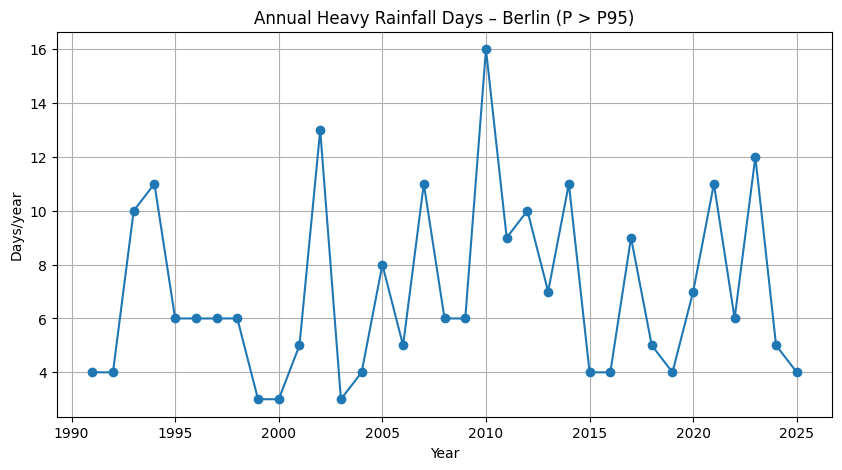

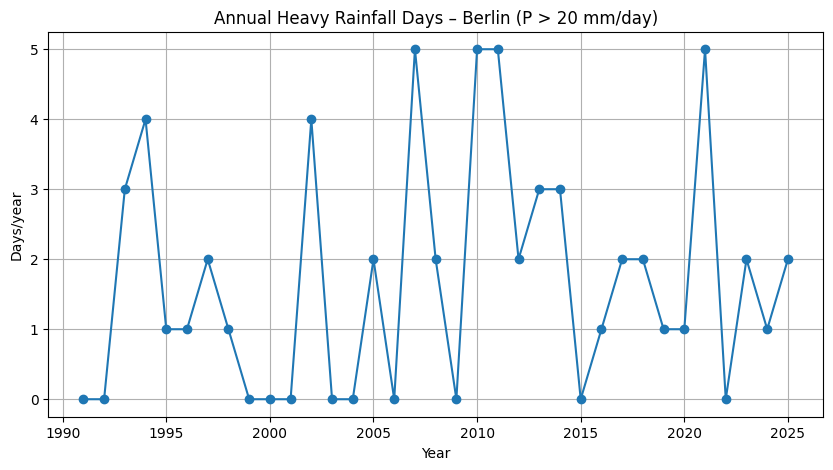

In [34]:
# Step 3 — Define baseline period and compute thresholds
baseline = pr_daily.sel(time=slice("1991-01-01", "2020-12-31"))

# Option A: Percentile threshold (P95)
wet = baseline.where(baseline > 1.0)

p95 = wet.quantile(0.95, dim="time", skipna=True)
print("P95 threshold (mm/day):", float(p95.values))

# Option B: Absolute threshold (e.g., 20 mm/day)
abs_thr = 20.0

# Step 4 — Identify extreme rainfall days
# A) Percentile-based extremes
extreme_p95 = pr_daily > p95

# B) Absolute threshold extremes (20 mm/day)
extreme_20mm = pr_daily > abs_thr

# Step 5 — Count extreme rainfall days per year
p95_counts = extreme_p95.groupby("time.year").sum().to_series()
mm20_counts = extreme_20mm.groupby("time.year").sum().to_series()

# Fill missing years with 0 (optional)
years = pd.Index(range(1991, 2026), name="year")
p95_counts = p95_counts.reindex(years, fill_value=0)
mm20_counts = mm20_counts.reindex(years, fill_value=0)

# Step 6 — Plot results
plt.figure(figsize=(10,5))
plt.plot(p95_counts.index, p95_counts.values, marker="o")
plt.title("Annual Heavy Rainfall Days – Berlin (P > P95)")
plt.xlabel("Year")
plt.ylabel("Days/year")
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(mm20_counts.index, mm20_counts.values, marker="o")
plt.title("Annual Heavy Rainfall Days – Berlin (P > 20 mm/day)")
plt.xlabel("Year")
plt.ylabel("Days/year")
plt.grid(True)
plt.show()


**Percentile-Based Threshold (P > P95)**
- Large year-to-year variability
- Some high years (2002, 2010, 2022)
- No obvious strong monotonic upward trend

This is typical of precipitation extremes:
- High interannual variability
- Strong influence of atmospheric circulation patterns
- Much noisier than temperature extremes

**Absolute Threshold (P > 20 mm/day)**
These values are lower:
- Mostly 0–5 days per year
- Many years with 0–2 events

This is also realistic.

Heavy rainfall >20 mm/day:
- Rare in Berlin
- Occasional cluster years
- Strongly weather-driven

Heavy rainfall days in Berlin exhibit strong interannual variability. 

Unlike heatwaves, which show a clear increasing trend, extreme precipitation does not display a strong monotonic increase over the 1991–2025 period.

The percentile-based metric (P > P95) yields approximately 3–12 extreme rainfall days per year, with occasional spike years. The absolute threshold (P > 20 mm/day) shows fewer events (0–5 days per year), reflecting the rarity of high-intensity rainfall.

This contrast with heatwave trends illustrates an important climate science insight:

- Temperature extremes show a strong forced signal.
- Precipitation extremes exhibit higher internal variability.
- Detecting statistically robust trends in rainfall requires longer records and spatial aggregation.

Thus, statistical significance does not always align with visual variability, and rainfall trend detection is inherently more uncertain than temperature trend detection.


### Mann–Kendall Test:

In [35]:
import pymannkendall as mk

mk_p95 = mk.original_test(p95_counts.values)
mk_20 = mk.original_test(mm20_counts.values)

print("Mann–Kendall (P > P95):", mk_p95.trend, "p=", mk_p95.p, "Sen slope=", mk_p95.slope)
print("Mann–Kendall (P > 20mm):", mk_20.trend, "p=", mk_20.p, "Sen slope=", mk_20.slope)

Mann–Kendall (P > P95): no trend p= 0.47258520740133436 Sen slope= 0.0
Mann–Kendall (P > 20mm): no trend p= 0.34901775116764266 Sen slope= 0.0


**Why No Significant Trend?**

The absence of statistical significance does not mean that extreme rainfall is not changing.

It means that:

- The signal-to-noise ratio is low.
- Interannual variability dominates.
- Longer records or spatial aggregation may be required to detect a robust trend.

This highlights an important contrast:

Temperature extremes respond directly to radiative forcing.
Precipitation extremes depend strongly on atmospheric dynamics and are inherently noisier.

# 6. Exercise Part C — Drought Duration

Drought is not simply low rainfall in one day.

It is:
- Persistent absence of rainfall
- Soil moisture depletion
- Hydrological stress

One of the most widely used drought metrics in climate science is: **Consecutive Dry Days (CDD)**

This is part of the **ETCCDI (Expert Team on Climate Change Detection and Indices)** standard indices.

## Consecutive Dry Days (CDD)

A dry day is defined as:

$$
P(t) < 1 \text{ mm/day}
$$

where $P(t)$ is daily precipitation.

Consecutive Dry Days (CDD) are defined as the length of consecutive sequences of dry days:

$$
L_i = \text{length of consecutive days where } P(t) < 1
$$

The annual drought duration metric is:

$$
CDD_{year} = \max(L_i \text{ within year})
$$

CDD captures drought persistence rather than intensity.

**Why Use < 1 mm?**
- 0 mm is too strict (trace rainfall exists)
- 1 mm threshold is standard in ETCCDI
- Represents “effectively dry” conditions

### Why CDD Is Important
Long dry spells affect:
- Agriculture
- Soil moisture
- Forest fire risk
- Urban vegetation
- Water supply

Unlike heavy rainfall:
- Drought depends on persistence
- Multi-day structure matters

### Dataset

Since we have already downloaded Berlin precipitation data, we can use the same 

**ERA5 hourly time-series data on single levels from 1940 to present** 

dataset, by choosing "Total precipitation" as variable:


In [36]:
import cdsapi
from datetime import datetime
import zipfile
import os
import xarray as xr

def download_and_open_era5_timeseries(request, zip_target, extract_dir):
    client = cdsapi.Client()

    start = datetime.now()
    print(f"Starting download: {start:%Y-%m-%d %H:%M:%S}")
    print("Target:", zip_target)

    client.retrieve("reanalysis-era5-single-levels-timeseries", request, zip_target)

    end = datetime.now()
    print(f"Finished download: {end:%Y-%m-%d %H:%M:%S}")
    print(f"Duration: {end - start}")

    os.makedirs(extract_dir, exist_ok=True)

    with zipfile.ZipFile(zip_target, "r") as z:
        z.extractall(extract_dir)
        names = z.namelist()
        print("Extracted:", names)

    # pick the first NetCDF file
    nc_candidates = [os.path.join(extract_dir, n) for n in names if n.endswith(".nc")]
    if not nc_candidates:
        raise FileNotFoundError("No .nc file found inside the downloaded ZIP.")

    nc_path = nc_candidates[0]
    print("Opening:", nc_path)

    return xr.open_dataset(nc_path)

# --- usage ---
berlin_location = {"latitude": 52.5, "longitude": 13.5}

request = {
    "variable": ["total_precipitation"],
    "location": berlin_location,
    "date": ["1991-01-01/2025-12-18"],
    "data_format": "netcdf",
}

# Load Data
ds = download_and_open_era5_timeseries(
    request=request,
    zip_target="era5_berlin_precipitation_hourly_1991_2025.zip",
    extract_dir="era5_berlin_precipitation_timeseries_extracted"
)

print(ds)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Starting download: 2026-02-23 21:51:28
Target: era5_berlin_precipitation_hourly_1991_2025.zip


2026-02-23 21:51:29,105 INFO [2026-02-16T00:00:00] - To generate this ERA5 hourly time series dataset, **homogenisation conventions have been applied to the ERA5 source GRIB data** to ensure consistency, usability, and alignment across chosen variables and time steps. The processed data were then written to an **ARCO Zarr archive**, enabling efficient cloud-optimised access and scalable data retrieval. Please refer to the [user guide](https://confluence.ecmwf.int/x/R6cfHg) for details.

- The dataset presented here is a subset of selected parameters from the full [CDS ERA5 hourly data on single levels (1940–present)](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview). **Requirements for additional parameters may be considered**. Please raise your request with ECMWF Support [here](https://jira.ecmwf.int/plugins/servlet/desk/portal/1/create/202).
2026-02-23 21:51:29,107 INFO Request ID is 2be32a42-e448-4cca-9c89-39e21efc5eca
2026-02-23 21:51:29,213 INF

360ae084ecb585cf6c10a46e708892bd.zip:   0%|          | 0.00/3.52M [00:00<?, ?B/s]

Finished download: 2026-02-23 21:51:49
Duration: 0:00:20.289380
Extracted: ['reanalysis-era5-single-levels-timeseries-sfc57_1n1l2.nc']
Opening: era5_berlin_precipitation_timeseries_extracted/reanalysis-era5-single-levels-timeseries-sfc57_1n1l2.nc
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 306504)
Coordinates:
    latitude    float64 8B ...
    longitude   float64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2MB 1991-01-01 ... 2025-12-18T23:...
Data variables:
    tp          (valid_time) float32 1MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts


<xarray.DataArray 'precip_mm' (time: 12771)> Size: 51kB
array([1.0528564 , 4.0979385 , 4.917145  , ..., 0.        , 0.00619888,
       0.02336502], shape=(12771,), dtype=float32)
Coordinates:
    latitude   float64 8B ...
    longitude  float64 8B ...
  * time       (time) datetime64[ns] 102kB 1991-01-01 1991-01-02 ... 2025-12-18


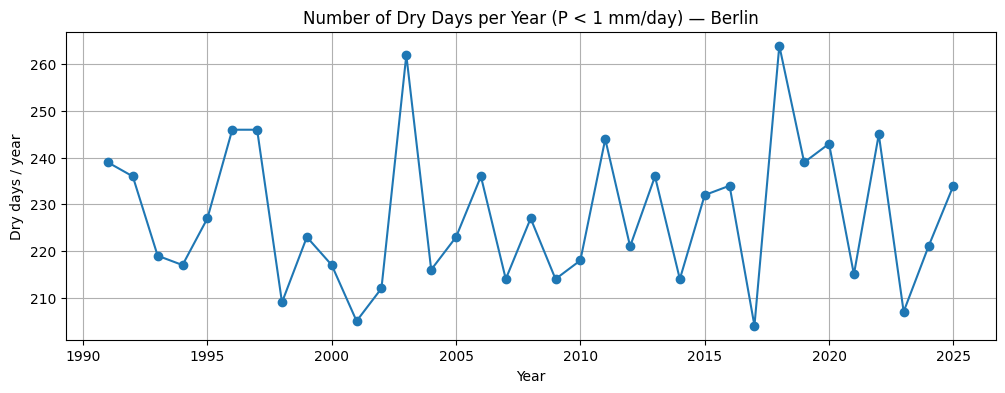

In [42]:
import matplotlib.pyplot as plt

# Step 1 — Convert Hourly to Daily Precipitation

# Convert from meters to millimeters
pr = ds["tp"] * 1000
pr.name = "precip_mm"

# Rename coordinate for convenience
pr = pr.rename({"valid_time": "time"})

# Daily total precipitation
pr_daily = pr.resample(time="1D").sum()

print(pr_daily)

# Step 2 — Identify Dry Days (< 1 mm)
dry_days = pr_daily < 1.0
dry_days.name = "dry_day"

dry_days_count = dry_days.groupby("time.year").sum()

plt.figure(figsize=(12,4))
plt.plot(dry_days_count["year"], dry_days_count.values, marker="o")
plt.title("Number of Dry Days per Year (P < 1 mm/day) — Berlin")
plt.xlabel("Year")
plt.ylabel("Dry days / year")
plt.grid(True)
plt.show()

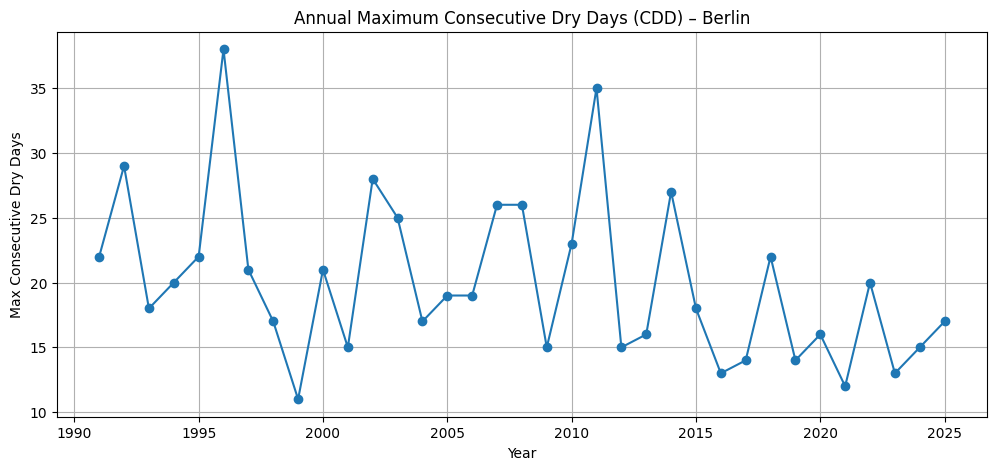

Trend: decreasing
p-value: 0.014342078562542993
Sen's slope: -0.21052631578947367


In [43]:
# Step 3 — Compute Consecutive Dry Day Streaks

# Convert to pandas Series
dry_series = dry_days.to_series()

# Identify change points
groups = (dry_series != dry_series.shift()).cumsum()

# Compute streak lengths
streak_lengths = dry_series.groupby(groups).cumsum()

# Keep only dry streaks
dry_streaks = streak_lengths.where(dry_series)

dry_streaks.head()

# Step 4 — Extract Annual Maximum CDD
# Put into DataFrame
df_streaks = dry_streaks.to_frame(name="streak")
df_streaks["year"] = df_streaks.index.year

# Annual maximum drought duration
cdd_annual = df_streaks.groupby("year")["streak"].max()

cdd_annual.head()

# Put into DataFrame
df_streaks = dry_streaks.to_frame(name="streak")
df_streaks["year"] = df_streaks.index.year

# Annual maximum drought duration
cdd_annual = df_streaks.groupby("year")["streak"].max()

cdd_annual.head()

# Step 5 — Plot Annual CDD
plt.figure(figsize=(12,5))
plt.plot(cdd_annual.index, cdd_annual.values, marker="o")
plt.title("Annual Maximum Consecutive Dry Days (CDD) – Berlin")
plt.xlabel("Year")
plt.ylabel("Max Consecutive Dry Days")
plt.grid(True)
plt.show()

# Step 6 — Mann–Kendall Trend Test
import pymannkendall as mk

mk_cdd = mk.original_test(cdd_annual.values)

print("Trend:", mk_cdd.trend)
print("p-value:", mk_cdd.p)
print("Sen's slope:", mk_cdd.slope)

The Mann–Kendall test detects a statistically significant decreasing trend in the annual maximum consecutive dry days.

Since:

$$p=0.014<0.05$$ 

we reject the null hypothesis of no monotonic trend at the 5% significance level.

The Sen’s slope estimate of:

$$−0.21 days/year$$

means that the longest dry spell in Berlin has shortened on average by approximately:

$$−0.21×10=−2.1 \text{ days per decade} $$

**Scientific Meaning**
This suggests:
- The longest uninterrupted dry periods have become shorter.
- Drought persistence (as defined by CDD) has decreased over 1991–2025.

This contrasts sharply with:
- Heatwaves → strong increase
- Heavy rainfall → no significant trend
- CDD → significant decrease

**This does not necessarily mean drought risk is decreasing.**

CDD measures only:

    Length of the longest uninterrupted dry spell.

It does not measure:
- Total summer dryness
- Soil moisture
- Evapotranspiration
- Water deficit
- Compound heat–drought effects

It is possible to have:
- Shorter dry streaks
- But higher evaporation
- And greater water stress

This is especially relevant under warming conditions.



# 7. Spatial Risk Mapping

## Spatial Risk Mapping

Climate risk is often conceptualized as:

$$
\text{Risk} = \text{Hazard} \times \text{Exposure} \times \text{Vulnerability}
$$

Where:

- Hazard = probability or intensity of extreme events
- Exposure = people, infrastructure, assets
- Vulnerability = sensitivity and adaptive capacity

In this exercise, we model only the **hazard component**, defined as:

$$
\text{Hazard}_{cell} = \text{trend in extreme frequency at grid cell}
$$

This provides a spatial representation of changing climate extremes.

### Grid-Based Trend Estimation

For each grid cell $(i,j)$:

$$
X_{i,j,t} = \text{number of extreme days in year } t
$$

We estimate the trend using Sen’s slope:

$$
\beta_{i,j} = \text{median slope of } X_{i,j,t}
$$

Statistical significance is evaluated using the Mann–Kendall test:

$$
H_0: \text{No monotonic trend}
$$

Cells with $p < 0.05$ are considered statistically significant.

## Dataset

For this exercise, we are going to download "ERA5 post-processed daily statistics on single levels from 1940 to present" dataset(https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=download)

With the settings: 
- Product Type: Reanalysis
- Variable: 2m temperature
- Daily Statistic: Daily Maximum
- All months, all days in the years 1991-2020.

Due to restrictions for downloading the dataset, we are using a script again to download the dataset that can take a very long time to dowload each year individually in a file; it can take 4-5 hours to download the whole dataset, depending on the traffic at the time.


In [5]:
import cdsapi
from datetime import datetime
import os, time
import random

client = cdsapi.Client()

OUT_DIR = "era5_tmax_daily_ce"
os.makedirs(OUT_DIR, exist_ok=True)

AREA = [55, 5, 47, 20]  # Central Europe
MONTHS = ["05", "06", "07", "08", "09"]
DAYS = [f"{d:02d}" for d in range(1, 32)]

BASE_REQUEST = {
    "product_type": "reanalysis",
    "variable": "2m_temperature",
    "month": MONTHS,
    "day": DAYS,
    "daily_statistic": "daily_maximum",
    "time_zone": "utc+00:00",
    "frequency": "6_hourly",   # keep if mandatory; cheaper than 1_hourly
    "area": AREA,
    "format": "netcdf",
}

def download_year(year: int, max_retries=5, cooldown_s=45):
    target = os.path.join(OUT_DIR, f"era5_tmax_daily_ce_{year}.nc")
    if os.path.exists(target) and os.path.getsize(target) > 0:
        print(f"✅ {year} already exists")
        return True

    req = dict(BASE_REQUEST)
    req["year"] = str(year)

    backoff = 30  # seconds
    for attempt in range(1, max_retries + 1):
        start = datetime.now()
        print(f"⬇️  {year} attempt {attempt}/{max_retries} start {start:%H:%M:%S}")

        try:
            client.retrieve("derived-era5-single-levels-daily-statistics", req, target)
            end = datetime.now()
            print(f"✅ {year} done in {end-start}")

            # polite cooldown (plus jitter so we don't look like a bot)
            sleep_for = cooldown_s + random.randint(0, 30)
            print(f"😴 Cooldown {sleep_for}s")
            time.sleep(sleep_for)
            return True

        except Exception as e:
            end = datetime.now()
            print(f"⚠️  {year} failed after {end-start}: {e}")

            # exponential backoff + jitter
            sleep_for = backoff + random.randint(0, 30)
            print(f"⏳ Backing off {sleep_for}s before retry...")
            time.sleep(sleep_for)
            backoff = min(backoff * 2, 15 * 60)  # cap at 15 min

    print(f"❌ {year} failed after {max_retries} attempts")
    return False

for y in range(1991, 2021):
    ok = download_year(y)
    if not ok:
        print("Stopping loop due to repeated failures.")
        break

✅ 1991 already exists
✅ 1992 already exists
✅ 1993 already exists
✅ 1994 already exists
✅ 1995 already exists
✅ 1996 already exists
✅ 1997 already exists
⬇️  1998 attempt 1/5 start 11:17:17


2026-02-24 11:17:17,879 INFO Request ID is 97885716-a266-40d9-b2a5-8b8c02546839
2026-02-24 11:17:17,992 INFO status has been updated to accepted
2026-02-24 12:42:13,800 INFO status has been updated to successful


c84ce61be0639823e85a31d9d9a6eeaa.nc:   0%|          | 0.00/526k [00:00<?, ?B/s]

✅ 1998 done in 1:24:58.196351
😴 Cooldown 58s
⬇️  1999 attempt 1/5 start 12:43:13


2026-02-24 12:43:14,416 INFO Request ID is 0b4e8331-4f40-4998-bc00-cfb897489258
2026-02-24 12:43:14,526 INFO status has been updated to accepted
2026-02-24 13:42:15,924 INFO status has been updated to successful


...

ac343aca88fecfdc6d672d71570e2544.nc:   0%|          | 0.00/530k [00:00<?, ?B/s]

✅ 2019 done in 0:00:35.192247
😴 Cooldown 58s
⬇️  2020 attempt 1/5 start 16:44:25


2026-02-24 16:44:26,513 INFO Request ID is 3529a547-7dc5-476a-80cf-f13ba63400b6
2026-02-24 16:44:26,648 INFO status has been updated to accepted
2026-02-24 16:48:47,855 INFO status has been updated to successful


361df24263b1434721d51486801462aa.nc:   0%|          | 0.00/530k [00:00<?, ?B/s]

✅ 2020 done in 0:04:24.478159
😴 Cooldown 66s


In [6]:
# TODO:
# - Compute trend per grid cell
# - Map significant increases
# - Highlight hotspots


# Step 1: Load all yearly files into one dataset
import xarray as xr
import glob
import numpy as np
import pandas as pd

files = sorted(glob.glob("era5_tmax_daily_ce/era5_tmax_daily_ce_*.nc"))
ds = xr.open_mfdataset(files, combine="by_coords")
print(ds)
print("Vars:", list(ds.data_vars))

<xarray.Dataset> Size: 37MB
Dimensions:     (valid_time: 4590, latitude: 33, longitude: 61)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 264B 55.0 54.75 54.5 ... 47.5 47.25 47.0
  * longitude   (longitude) float64 488B 5.0 5.25 5.5 5.75 ... 19.5 19.75 20.0
  * valid_time  (valid_time) datetime64[ns] 37kB 1991-05-01 ... 2020-09-30
Data variables:
    t2m         (valid_time, latitude, longitude) float32 37MB dask.array<chunksize=(153, 33, 61), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-02-24T07:13 GRIB to CDM+CF via cfgrib-0.9.1...
Vars: ['t2m']


### Spatial Hazard Map

We define a heat-extreme hazard metric as the annual count of days where daily maximum temperature exceeds the local 90th percentile threshold (T90) for May–September.

For each grid cell, we compute:
- the trend in extreme hot-day frequency (days per decade)
- the statistical significance of the trend (OLS p-value)

Cells highlighted as “hotspots” satisfy:
$$
p < 0.05 \quad \text{and} \quad \text{slope} > 0
$$

This map represents the **hazard** component of climate risk. It does not include exposure (population/assets) or vulnerability (sensitivity/adaptive capacity).

In [7]:
# Step 2: Pick the temperature variable
tvar = list(ds.data_vars)[0]  # if there's only one
print("Using:", tvar)
da = ds[tvar]

# Rename time coordinate if needed
if "valid_time" in da.dims:
    da = da.rename({"valid_time": "time"})

# Convert Kelvin → Celsius if needed
# heuristic: if values are around 250–330, it's Kelvin
if float(da.mean().values) > 100:
    da_c = da - 273.15
else:
    da_c = da

da_c.name = "tmax_c"

# Step 3: Define the hazard metric: “heatwave days”
# 90th percentile threshold per grid cell for the whole May–Sep season (baseline)
t90 = da_c.quantile(0.90, dim="time", skipna=True)
t90.name = "t90"

# Boolean array: hot extreme days
hot = da_c > t90
hot.name = "hot_day"

# Step 4: Count hot extreme days per year per grid cell
hot_days_per_year = hot.groupby("time.year").sum(dim="time")
hot_days_per_year.name = "hot_days"
print(hot_days_per_year)

Using: t2m
<xarray.DataArray 'hot_days' (year: 30, latitude: 33, longitude: 61)> Size: 483kB
dask.array<stack, shape=(30, 33, 61), dtype=int64, chunksize=(1, 33, 61), chunktype=numpy.ndarray>
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 264B 55.0 54.75 54.5 54.25 ... 47.5 47.25 47.0
  * longitude  (longitude) float64 488B 5.0 5.25 5.5 5.75 ... 19.5 19.75 20.0
    quantile   float64 8B 0.9
  * year       (year) int64 240B 1991 1992 1993 1994 ... 2017 2018 2019 2020


/home/nicolae/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/nicolae/.local/lib/python3.10/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_rivers_lake_centerlines.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


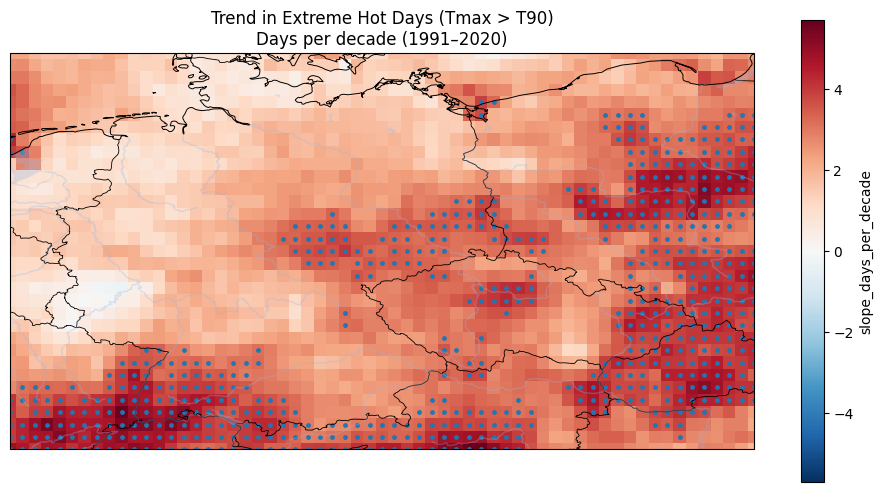

In [10]:
# Step 5: Trend per grid cell
from scipy.stats import linregress

years = hot_days_per_year["year"].values.astype(float)

def ols_slope_p(y):
    # y is 1D over years
    mask = np.isfinite(y)
    if mask.sum() < 10:
        return np.nan, np.nan
    res = linregress(years[mask], y[mask])
    return res.slope, res.pvalue

# Apply over grid (vectorized via apply_ufunc)
hot_days_per_year = hot_days_per_year.chunk({"year": -1})
slope, pval = xr.apply_ufunc(
    ols_slope_p,
    hot_days_per_year,
    input_core_dims=[["year"]],
    output_core_dims=[[], []],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float, float],
)

slope.name = "slope_days_per_year"
pval.name = "p_value"

# Convert slope to days/decade (more interpretable)
slope_decade = slope * 10
slope_decade.name = "slope_days_per_decade"

# Significance mask:
sig = pval < 0.05
sig.name = "significant"

# Hotspots (significant increase only):
hotspots = sig & (slope_decade > 0)
hotspots.name = "hotspots"

# Step 6: Plotting with Cartopy (trend + hotspot overlay)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj)

# background
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.6)
ax.add_feature(cfeature.LAKES, alpha=0.3)
ax.add_feature(cfeature.RIVERS, alpha=0.3)

# extent: Central Europe box you used
ax.set_extent([5, 20, 47, 55], crs=proj)

# trend heatmap
im = slope_decade.plot(
    ax=ax,
    transform=proj,
    add_colorbar=True
)
ax.set_title("Trend in Extreme Hot Days (Tmax > T90)\nDays per decade (1991–2020)")

# overlay hotspots (significant positive trend)
# draw as points (stipple)
yy, xx = np.meshgrid(slope_decade["latitude"].values, slope_decade["longitude"].values, indexing="ij")
mask = hotspots.values

ax.scatter(
    xx[mask], yy[mask],
    s=6,
    transform=proj
)

plt.show()

### What the map shows

The map displays:

    slope (days per decade)

in the annual number of extreme hot days (Tmax > T90) for each grid cell.
- Red colors → increase in extreme hot days
- Blue colors → decrease
- Dots → statistically significant increase (p < 0.05)

**Identified Hotspots**

Significant clusters (stippled areas) appear:
- Eastern Germany (including the Berlin–Brandenburg region)
- Czech Republic
- Eastern Austria (Vienna region)
- Parts of southern Poland and northern Balkans

These are statistically significant increasing hazard zones.

**Why Berlin & Vienna Stand Out**

We are likely observing:
- Continental interior amplification
- Lower maritime moderation
- Strong summer blocking patterns in recent decades
- Urban heat island contribution (locally)

Eastern Germany and Austria are:
- Less influenced by Atlantic air masses
- More exposed to persistent high-pressure systems

This aligns with observed heatwave intensification in Central/Eastern Europe.


# 8. Extreme Value Statistics 

So far, we focused on **frequency-based extremes** (e.g., number of hot days above T90).  
Extreme Value Theory (EVT) answers a different question:

> How large can extremes get, and how often should we expect them?

This is central for engineering design and climate risk planning (e.g., “100-year heat event”).

---

## Block Maxima Concept

A common EVT approach is the **block maxima method**:

- Choose a block (typically 1 year)
- Extract the maximum value in that block

Let $X(t)$ be a daily variable (e.g., daily maximum temperature).  
Define the annual maximum:

$$
M_y = \max \{ X(t) : t \in \text{year } y \}
$$

The sequence $\{M_y\}$ (one value per year) is modeled using the **Generalized Extreme Value (GEV)** distribution.

---

## Generalized Extreme Value (GEV) Distribution

The GEV distribution is a family of distributions used to model block maxima:

$$
M_y \sim \text{GEV}(\mu, \sigma, \xi)
$$

Parameters:

- $\mu$ = location (typical magnitude of extremes)
- $\sigma > 0$ = scale (variability of extremes)
- $\xi$ = shape (tail behavior / boundedness)

The cumulative distribution function (CDF) is:

$$
F(x) = \exp\left( - \left[ 1 + \xi\left(\frac{x - \mu}{\sigma}\right)\right]^{-1/\xi} \right)
$$

Valid when:

$$
1 + \xi\left(\frac{x - \mu}{\sigma}\right) > 0
$$

Special case (Gumbel) when \(\xi \to 0\):

$$
F(x) = \exp\left( -\exp\left(-\frac{x-\mu}{\sigma}\right) \right)
$$

---

## Return Levels and Return Periods

A **return period** $T$ years corresponds to an exceedance probability of:

$$
p = \frac{1}{T}
$$

A **return level** $z_T$ is the value expected to be exceeded on average once every \(T\) years:

$$
P(M > z_T) = \frac{1}{T}
$$

Equivalently:

$$
F(z_T) = 1 - \frac{1}{T}
$$

For a **100-year event**:

$$
F(z_{100}) = 0.99
$$

Once the GEV parameters are fitted, we can compute $z_{100}$.

---

## Comparing Early vs Recent Periods

To assess whether extremes have intensified, we fit GEV models separately for two periods:

- Early period (e.g., 1991–2005)
- Recent period (e.g., 2006–2020)

We compare:

- changes in fitted parameters ($\mu, \sigma, \xi$)
- changes in return levels (e.g., $z_{50}$, $z_{100}$)

If $z_{100}$ increases in the recent period, it suggests that rare extremes have become more intense.

---

## Interpretation Caveat (Very Important)

Estimating a “100-year event” from ~30 years of observations involves large uncertainty.

Key point:

- A 100-year return level is an **extrapolation** beyond the observed sample length.
- Confidence intervals can be wide.
- The result should be interpreted as a model-based estimate, not a certainty.

This uncertainty is a core graduate-level learning outcome.

## Dataset

We use again *ERA5 hourly time-series data on single levels from 1940 to present* (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview) from Copernicus Climate Data Store. With the variables:

- Variable: 2m temperature
- Frequency: Daily
- Period: 1991–2025
- Units: Kelvin (converted to Celsius)
- Location: For Berlin (≈ 52.52°N, 13.41°E) we use the nearest grid point: (52.50°N, 13.50°E).

Since we already have the dataset from the Heatwave analysis, we just load the dataset:

In [11]:
# Load Berlin single-point daily 

import os
import zipfile
import xarray as xr

path = "era5_berlin_t2m_hourly_1991_2025.nc"

def open_era5_netcdf_or_zip(path, extract_dir="era5_berlin_extract"):
    # If it's a ZIP archive with a .nc inside, extract it first.
    if zipfile.is_zipfile(path):
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(path, "r") as z:
            z.extractall(extract_dir)
            nc_files = [os.path.join(extract_dir, n) for n in z.namelist() if n.endswith(".nc")]
            if not nc_files:
                raise FileNotFoundError("ZIP did not contain any .nc files.")
            nc_path = nc_files[0]
        print("Detected ZIP. Extracted:", nc_path)
        return xr.open_dataset(nc_path)
    else:
        return xr.open_dataset(path)

ds = open_era5_netcdf_or_zip(path)
print(ds)
print("Vars:", list(ds.data_vars))

Detected ZIP. Extracted: era5_berlin_extract/reanalysis-era5-single-levels-timeseries-sfc63qwb7ba.nc
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 306504)
Coordinates:
    latitude    float64 8B ...
    longitude   float64 8B ...
  * valid_time  (valid_time) datetime64[ns] 2MB 1991-01-01 ... 2025-12-18T23:...
Data variables:
    t2m         (valid_time) float32 1MB ...
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts
Vars: ['t2m']


Time dimension: valid_time


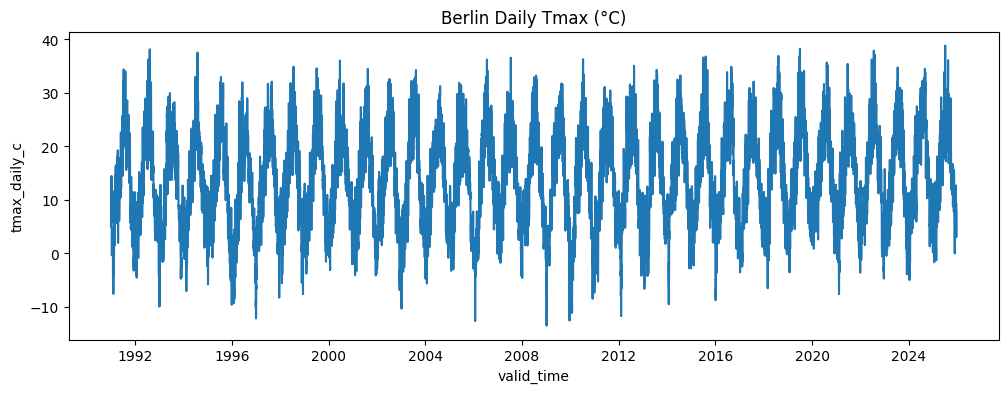

In [13]:
# Fix the time coordinate name
# Identify the time dimension name
time_dim = "valid_time" if "valid_time" in ds.dims else "time"
print("Time dimension:", time_dim)

import numpy as np

t2m = ds["t2m"]  # in Kelvin
t2m_c = t2m - 273.15
t2m_c.name = "t2m_c"

# Daily maximum temperature
tmax_daily = t2m_c.resample({time_dim: "1D"}).max()
tmax_daily.name = "tmax_daily_c"

tmax_daily

# quick plot sanity check:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
tmax_daily.plot()
plt.title("Berlin Daily Tmax (°C)")
plt.show()

In [14]:
# Choose the “block” for block maxima: Keep only May–September
tmax_mjj = tmax_daily.sel({time_dim: tmax_daily[time_dim].dt.month.isin([5,6,7,8,9])})
tmax_mjj.name = "tmax_mjj_c"

# Annual block maxima series
annual_max = tmax_mjj.groupby(tmax_mjj[time_dim].dt.year).max()
annual_max.name = "annual_block_max_c"

# annual_max = tmax_mjj.groupby(tmax_mjj[time_dim].dt.year).max()
annual_max.name = "annual_block_max_c"

# Convert to a NumPy array (GEV fit needs 1D values):
block_max = annual_max.values
years = annual_max["year"].values
block_max = block_max[np.isfinite(block_max)]
print("Number of annual maxima:", len(block_max))
print("Range (°C):", float(np.min(block_max)), "to", float(np.max(block_max)))

Number of annual maxima: 35
Range (°C): 29.981903076171875 to 38.846954345703125


In [15]:
# Fit a GEV distribution (SciPy)
from scipy.stats import genextreme

# Fit GEV to block maxima
c, loc, scale = genextreme.fit(block_max)

print("GEV fit parameters:")
print("shape (c):", c)
print("location (loc):", loc)
print("scale (scale):", scale)

GEV fit parameters:
shape (c): 0.36475816271544775
location (loc): 33.89789337220887
scale (scale): 2.3080973317418962


In [16]:
# Return levels (50-year and 100-year)
def return_level(T, c, loc, scale):
    q = 1 - 1/T
    return genextreme.ppf(q, c, loc=loc, scale=scale)

z50 = return_level(50, c, loc, scale)
z100 = return_level(100, c, loc, scale)

print(f"Estimated 50-year return level (summer Tmax):  {z50:.2f} °C")
print(f"Estimated 100-year return level (summer Tmax): {z100:.2f} °C")

Estimated 50-year return level (summer Tmax):  38.70 °C
Estimated 100-year return level (summer Tmax): 39.04 °C


In [17]:
# Compare early vs recent period
early = annual_max.sel(year=slice(1991, 2005)).values
recent = annual_max.sel(year=slice(2006, 2020)).values

early = early[np.isfinite(early)]
recent = recent[np.isfinite(recent)]

c_e, loc_e, scale_e = genextreme.fit(early)
c_r, loc_r, scale_r = genextreme.fit(recent)

z100_e = return_level(100, c_e, loc_e, scale_e)
z100_r = return_level(100, c_r, loc_r, scale_r)

print("Early period GEV:", (c_e, loc_e, scale_e))
print("Recent period GEV:", (c_r, loc_r, scale_r))
print()
print(f"100-year return level (early):  {z100_e:.2f} °C")
print(f"100-year return level (recent): {z100_r:.2f} °C")
print(f"Change in 100-year return level: {z100_r - z100_e:.2f} °C")

Early period GEV: (np.float64(0.17887189595165787), np.float64(32.92661903500543), np.float64(2.0385341842548157))
Recent period GEV: (np.float64(0.49976423272171977), np.float64(34.32864929105572), np.float64(2.231512972285694))

100-year return level (early):  39.32 °C
100-year return level (recent): 38.35 °C
Change in 100-year return level: -0.97 °C


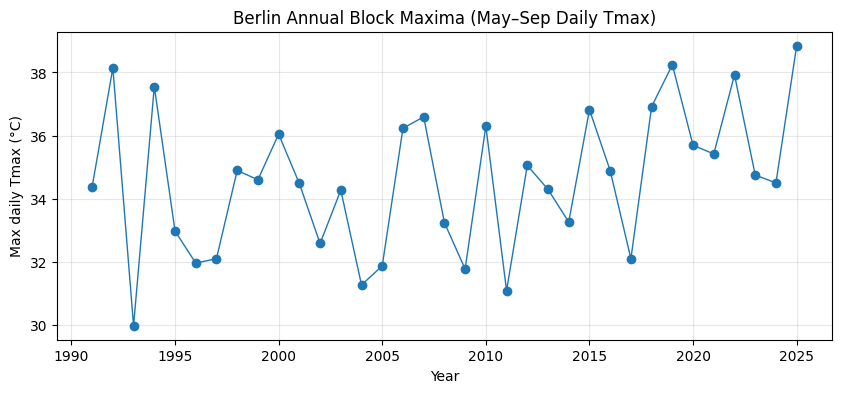

In [18]:
plt.figure(figsize=(10,4))
plt.plot(years, annual_max.values, marker="o", linewidth=1)
plt.title("Berlin Annual Block Maxima (May–Sep Daily Tmax)")
plt.xlabel("Year")
plt.ylabel("Max daily Tmax (°C)")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretation (GEV / Return Levels)

We apply the block-maxima approach by extracting the annual maximum of daily Tmax during May–September in Berlin.  
These annual maxima are modeled using the Generalized Extreme Value (GEV) distribution.

From the fitted GEV, we estimate return levels $z_T$ such that:

$$
F(z_T) = 1 - \frac{1}{T}
$$

The **100-year return level** represents a model-based estimate of a rare extreme that has ~1% chance of being exceeded in any given year.

We then fit separate GEV models to an early period and a recent period.  
If the recent-period $z_{100}$ is higher, this suggests intensification of rare heat extremes.

**Caveat:** With ~30 years of data, estimating a 100-year event is extrapolation and has substantial uncertainty. Bootstrap confidence intervals help quantify this uncertainty.

# 9. Synthesis and Assignment suggestion

# Synthesis: What We Learned (Lecture 2)

This notebook demonstrated three complementary ways to analyze climate extremes:

1. **Frequency-based extremes**  
   We counted extreme hot days (e.g., \(T_{\max} > T_{90}\)) to measure how often hazardous conditions occur.

2. **Persistence-based extremes**  
   We quantified multi-day structure, such as heatwave sequences and drought duration (CDD).

3. **Magnitude-based extremes (EVT)**  
   Using **block maxima**, we modeled the annual maximum summer temperature with the **GEV distribution** to estimate rare-event intensity (return levels).

## Key takeaway

- Climate extremes can change via **frequency**, **persistence**, and/or **magnitude**.
- EVT focuses on magnitude and enables risk-relevant statements like *“a 100-year event.”*
- However, estimating a 100-year event from ~30 years of data is **extrapolation** with substantial uncertainty.

---

# Assignment Suggestions 

## A) Reproduce + Extend 
1. Fit a GEV model to Berlin’s **summer** annual maxima.
2. Estimate $z_{50}$ and $z_{100}$ return levels.
3. Split into early vs recent periods and compare return levels.

## B) Uncertainty Quantification 
- Use bootstrap resampling to compute a 95% confidence interval for $z_{100}$.
- Discuss why uncertainty increases for return periods longer than the record length.

## C) Interpretation & Policy Relevance (
Write a short discussion (≈ 300–600 words):
- What does a “100-year temperature event” mean in practice?
- Why does “statistical significance” not automatically imply “policy relevance”?
- What types of adaptation planning might use these estimates (e.g., urban heat action plans)?

## D) Equity / Vulnerability Lens
Pick one:
- Identify who is most exposed/vulnerable in Berlin during extreme heat (e.g., elderly, low-income, indoor workers).
- Suggest one adaptation intervention and discuss trade-offs.
